In [1]:
from m_g_k import MGKQueue, Server
import matplotlib.pyplot as plt
import numpy.random as rng
import scipy.stats as stats

rng.uniform()

0.8345874514154807

In [2]:
class ModelConfig:
    def __init__(self, servers, arrival_generator, label):
        self.servers = servers
        self.arrival_generator = arrival_generator
        self.label = label

model_config = ModelConfig(
    servers=[
        Server(lambda: rng.exponential(1/2), lambda: 1),
        Server(lambda: rng.exponential(1/2), lambda: 2),
        Server(lambda: rng.exponential(1/2), lambda: 3),
    ],
    arrival_generator=lambda: rng.exponential(1/6),
    label="Model 1: 2 servers, arrival rate 6"
)
model_config_2 = ModelConfig(
    servers=[
        Server(lambda: rng.exponential(1/2), lambda: 1),
        Server(lambda: rng.exponential(1/2), lambda: 2),
        Server(lambda: rng.exponential(1/2), lambda: 3),
    ],
    arrival_generator=lambda: rng.exponential(1/6),
    label="Model 1: 2 servers, arrival rate 6"
)

SIMULATION_LENGTH = 60 * 8
CONFIDENCE_LEVEL = 0.95
ACCEPTED_ERROR = 1/10

In [ ]:
def perform_simulations(amount: int, model_config: ModelConfig) -> list[MGKQueue]:
    simulations = []
    for i in range(amount):
        if i % 1000 == 0: print("Simulating", i)
        model = MGKQueue(
            servers=model_config.servers,
            arrival_generator=model_config.arrival_generator,
            end_time=SIMULATION_LENGTH,
        )
        model.run()
        simulations.append(model)

    return simulations

def get_wait_time_stats(simulation_amount: int, model_config: ModelConfig) -> list[float]:
    wait_times = []
    for i in range(simulation_amount):
        if i%1000 == 0: print("Simulating", i)
        model = MGKQueue(
            servers=model_config.servers,
            arrival_generator=model_config.arrival_generator,
            end_time=SIMULATION_LENGTH,
        )
        model.run()
        wait_times += get_wait_times(model)

    return wait_times

def get_wait_times(model: MGKQueue):
    wait_times = [v + model.time_in_queue[k] for k, v in model.time_in_service.items()]
    return wait_times

def get_average_waiting_time(wait_times: list[float]):
    return sum(wait_times) / len(wait_times) if wait_times else 0

def get_variance_waiting_time(avg: float, wait_times: list[float]):
    return sum((x - avg) ** 2 for x in wait_times) / len(wait_times) if wait_times else 0

class AverageWaitTimeAnalysis:
    def __init__(self, average: float, variance: float, error_bound: float, sample_size: int):
        self.average = average
        self.variance = variance
        self.error_bound = error_bound
        self.sample_size = sample_size
    
    def __str__(self):
        return (f"Average Wait Time: {self.average:.2f}\n"
                f"Variance: {self.variance:.2f}\n"
                f"Error Bound: {self.error_bound:.2f}\n"
                f"Sample Size: {self.sample_size}")

def analyse_average_wait_time(model_config: ModelConfig, accepted_error: float, confidence_level: float) -> AverageWaitTimeAnalysis:
    z_value = stats.norm.ppf((1 + confidence_level) / 2)
    def get_error_bound(variance: float, sample_size: int):
        return z_value * (variance / (sample_size ** 0.5))

    wait_times = get_wait_time_stats(10000, model_config)
    avg_wait_time = get_average_waiting_time(wait_times)
    variance_wait_time = get_variance_waiting_time(avg_wait_time, wait_times)
    error_bound = get_error_bound(variance_wait_time, len(wait_times))

    while error_bound > accepted_error:
        print(f"Error bound is too large: {error_bound:.2f} > {accepted_error:.2f}, running more simulations...")
        
        wait_times += get_wait_time_stats(30, model_config)
        avg_wait_time = get_average_waiting_time(wait_times)
        variance_wait_time = get_variance_waiting_time(avg_wait_time, wait_times)
        error_bound = get_error_bound(variance_wait_time, len(wait_times))

    return AverageWaitTimeAnalysis(
        average=avg_wait_time,
        variance=variance_wait_time,
        error_bound=error_bound,
        sample_size=len(wait_times),
    )

In [4]:
model_1_analysis = analyse_average_wait_time(
    model_config,
    accepted_error=ACCEPTED_ERROR,
    confidence_level=CONFIDENCE_LEVEL,
)
model_2_analysis = analyse_average_wait_time(
    model_config_2,
    accepted_error=ACCEPTED_ERROR,
    confidence_level=CONFIDENCE_LEVEL,
)

Simulating 0
Simulating 1000
Simulating 2000
Simulating 3000
Simulating 4000
Simulating 5000
Simulating 6000
Simulating 7000
Simulating 8000
Simulating 9000
Simulating 0
Simulating 1000
Simulating 2000
Simulating 3000
Simulating 4000
Simulating 5000
Simulating 6000
Simulating 7000
Simulating 8000
Simulating 9000


In [5]:
print("Model 1 Analysis:")
print(model_1_analysis)
print("\nModel 2 Analysis:")
print(model_2_analysis)


Model 1 Analysis:
Average Wait Time: 6.99
Variance: 35.43
Error Bound: 0.01
Sample Size: 28811427

Model 2 Analysis:
Average Wait Time: 7.03
Variance: 36.30
Error Bound: 0.01
Sample Size: 28817448


Z Statistic: -27.30
Critical Value: 1.96
The two models are significantly different.


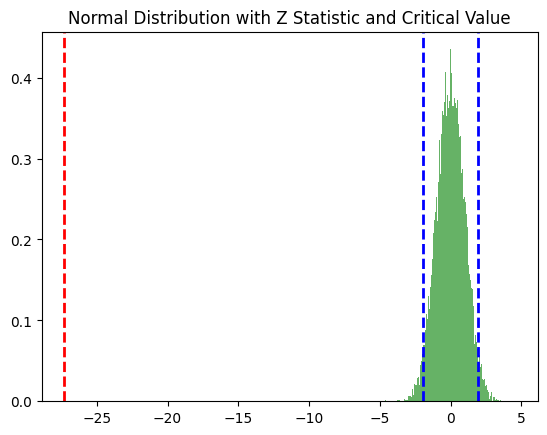

In [6]:
def calculate_z_statistic(model_1_analysis: AverageWaitTimeAnalysis, model_2_analysis: AverageWaitTimeAnalysis):
    return (model_1_analysis.average - model_2_analysis.average) / (model_1_analysis.variance / model_1_analysis.sample_size + model_2_analysis.variance / model_2_analysis.sample_size) ** 0.5

def calculate_critical_value(confidence_level: float):
    return stats.norm.ppf((1 + confidence_level) / 2)

# plot a normal distribution with the z statistic
def plot_normal_distribution(z_statistic: float, critical_value: float):
    x = stats.norm.rvs(size=100000)
    plt.hist(x, bins=1000, density=True, alpha=0.6, color='g')
    plt.axvline(z_statistic, color='r', linestyle='dashed', linewidth=2)
    plt.axvline(critical_value, color='b', linestyle='dashed', linewidth=2)
    plt.axvline(-critical_value, color='b', linestyle='dashed', linewidth=2)
    plt.title('Normal Distribution with Z Statistic and Critical Value')
    plt.show()

z_statistic = calculate_z_statistic(model_1_analysis, model_2_analysis)
critical_value = calculate_critical_value(CONFIDENCE_LEVEL)
print(f"Z Statistic: {z_statistic:.2f}")
print(f"Critical Value: {critical_value:.2f}")
if abs(z_statistic) > critical_value:
    print("The two models are significantly different.")

plot_normal_distribution(z_statistic, critical_value)


In [8]:
sim = perform_simulations(1, model_config)[0]
sim.captured_states[-1]


Simulating 0


Snapshot(time=502.5703946153785, people_in_queue=0, people_serviced=[983, 934, 1004], free_servers={0, 1, 2}, servers_serving=set())